In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
df= pd.read_csv('HistoricalData_1757227840674.csv')
print(df.head())
print(df.tail())

         Date Close/Last     Volume     Open      High       Low
0  09/05/2025    $167.02  224441400  $168.03   $169.03   $164.07
1  09/04/2025    $171.66  141670100  $170.57   $171.86   $169.41
2  09/03/2025    $170.62  164424900  $171.06   $172.41  $168.875
3  09/02/2025    $170.78  231164900  $170.00  $172.379   $167.22
4  08/29/2025    $174.18  243257900  $178.11   $178.15  $173.145
            Date Close/Last     Volume     Open     High      Low
2509  09/14/2015    $0.5673  192465440   $0.569  $0.5707  $0.5643
2510  09/11/2015    $0.5663  301577320  $0.5583    $0.57  $0.5559
2511  09/10/2015    $0.5645  357075840  $0.5525  $0.5715  $0.5499
2512  09/09/2015    $0.5558  289385960  $0.5687  $0.5735  $0.5545
2513  09/08/2015     $0.567  238338720   $0.557  $0.5693  $0.5548


In [72]:
df.shape

(2514, 6)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        2514 non-null   object
 1   Close/Last  2514 non-null   object
 2   Volume      2514 non-null   int64 
 3   Open        2514 non-null   object
 4   High        2514 non-null   object
 5   Low         2514 non-null   object
dtypes: int64(1), object(5)
memory usage: 118.0+ KB


In [74]:
for col in ['Close/Last', 'Open', 'High', 'Low']:
    df[col] = df[col].str.replace('$', '', regex=False)  
    df[col] = df[col].str.replace(',', '', regex=False)  # remove commas if any
    df[col] = df[col].astype(float)
df['Close']=df['Close/Last']
df.drop(columns=['Close/Last'], inplace=True)
df['Volume']=df['Volume'].astype(float)
df['Date'] = pd.to_datetime(df['Date'])

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2514 non-null   datetime64[ns]
 1   Volume  2514 non-null   float64       
 2   Open    2514 non-null   float64       
 3   High    2514 non-null   float64       
 4   Low     2514 non-null   float64       
 5   Close   2514 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 118.0 KB


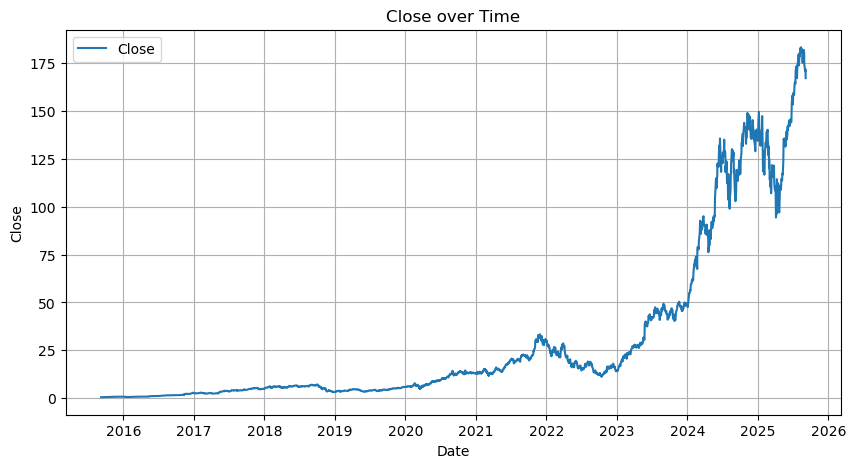

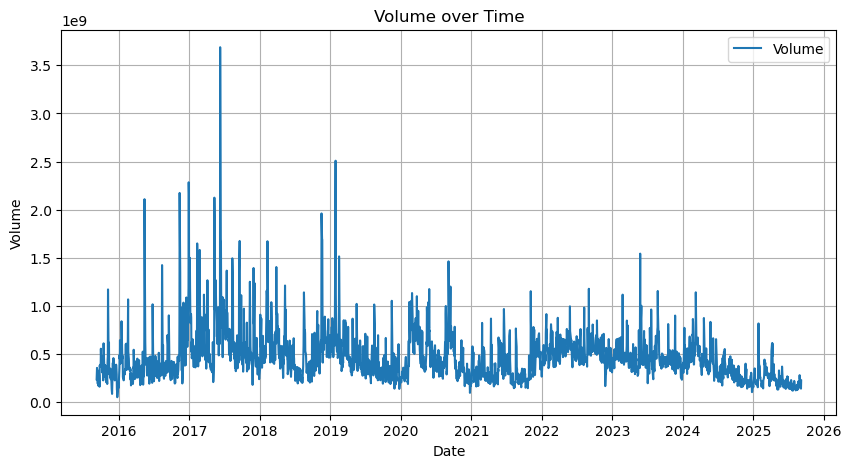

In [76]:
plot_cols = ['Close', 'Volume']
for col in plot_cols:
    plt.figure(figsize=(10, 5))
    plt.plot(df['Date'], df[col], label=col)
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.title(f'{col} over Time')
    plt.legend()
    plt.grid()
    plt.show()

In [77]:
from FeatureGenerator import FeatureGenerator

gen = FeatureGenerator(df)

In [78]:
new_features=gen.all_indicators()
print(new_features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SMA_20        2495 non-null   float64
 1   SMA_50        2465 non-null   float64
 2   SMA_200       2315 non-null   float64
 3   EMA_20        2514 non-null   float64
 4   EMA_50        2514 non-null   float64
 5   EMA_200       2514 non-null   float64
 6   MACD_Line     2514 non-null   float64
 7   MACD_Signal   2514 non-null   float64
 8   MACD_Hist     2514 non-null   float64
 9   RSI_7         2508 non-null   float64
 10  RSI_14        2501 non-null   float64
 11  RSI_21        2494 non-null   float64
 12  ROC_12        2502 non-null   float64
 13  ATR_14        2501 non-null   float64
 14  BB_Middle_20  2495 non-null   float64
 15  BB_Upper_20   2495 non-null   float64
 16  BB_Lower_20   2495 non-null   float64
 17  StochK_14     2499 non-null   float64
 18  StochD_14     2497 non-null 

In [79]:
df=df.join(new_features)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 30 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2514 non-null   datetime64[ns]
 1   Volume        2514 non-null   float64       
 2   Open          2514 non-null   float64       
 3   High          2514 non-null   float64       
 4   Low           2514 non-null   float64       
 5   Close         2514 non-null   float64       
 6   SMA_20        2495 non-null   float64       
 7   SMA_50        2465 non-null   float64       
 8   SMA_200       2315 non-null   float64       
 9   EMA_20        2514 non-null   float64       
 10  EMA_50        2514 non-null   float64       
 11  EMA_200       2514 non-null   float64       
 12  MACD_Line     2514 non-null   float64       
 13  MACD_Signal   2514 non-null   float64       
 14  MACD_Hist     2514 non-null   float64       
 15  RSI_7         2508 non-null   float64 

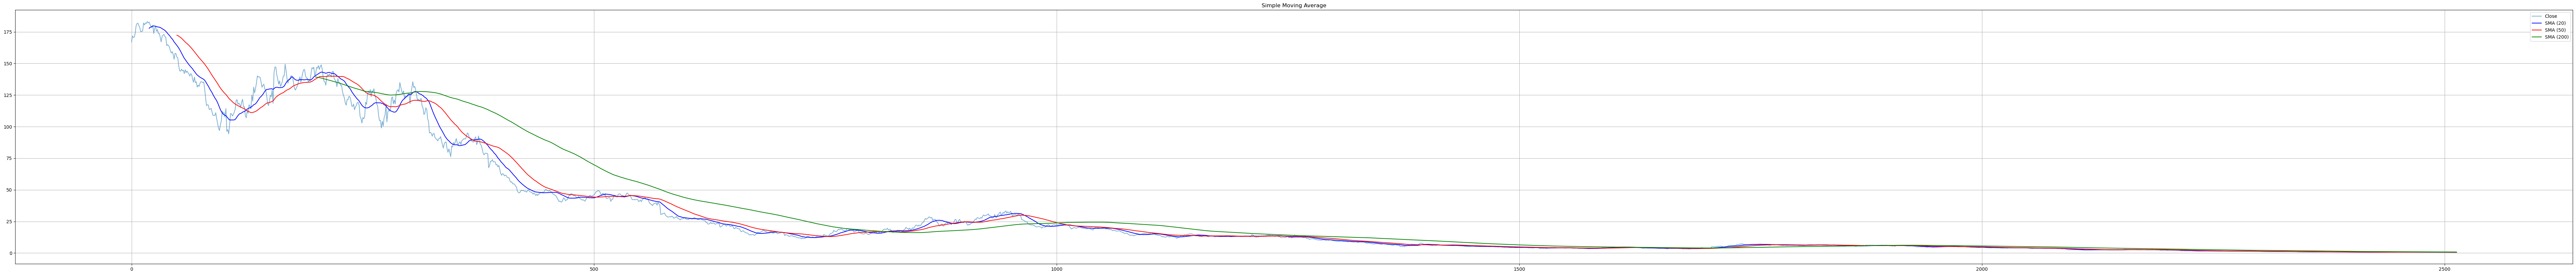

In [81]:
plt.figure(figsize=(100,10))
plt.plot(df.index, df['Close'], label="Close", alpha=0.6)
plt.plot(df.index, df['SMA_20'], label="SMA (20)", color="blue")
plt.plot(df.index, df['SMA_50'], label="SMA (50)", color="red")
plt.plot(df.index, df['SMA_200'], label="SMA (200)", color="green")
plt.title("Simple Moving Average")
plt.legend()
plt.grid(True)
plt.show()

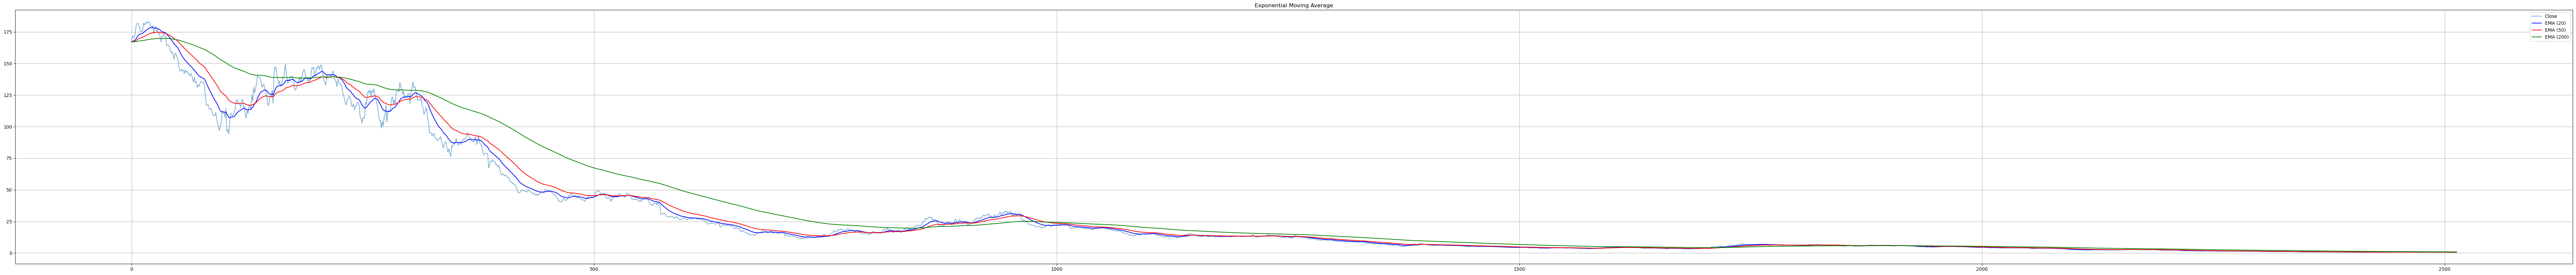

In [82]:
plt.figure(figsize=(100,10))
plt.plot(df.index, df['Close'], label="Close", alpha=0.6)
plt.plot(df.index, df['EMA_20'], label="EMA (20)", color="blue")
plt.plot(df.index, df['EMA_50'], label="EMA (50)", color="red")
plt.plot(df.index, df['EMA_200'], label="EMA (200)", color="green")
plt.title("Exponential Moving Average")
plt.legend()
plt.grid(True)
plt.show()

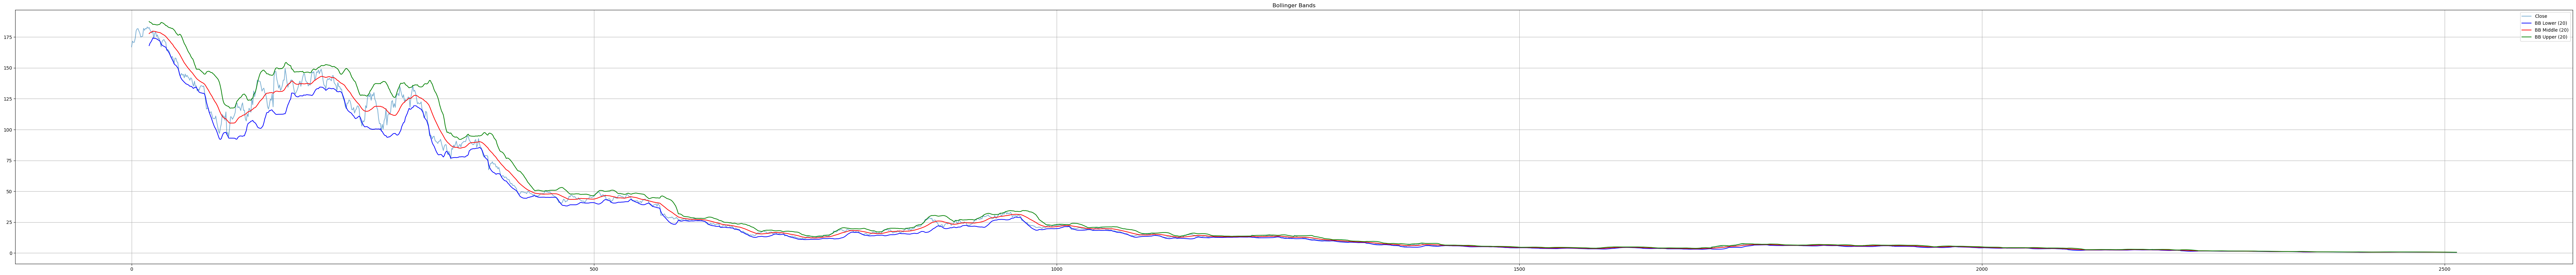

In [83]:
plt.figure(figsize=(100,10))
plt.plot(df.index, df['Close'], label="Close", alpha=0.6)
plt.plot(df.index, df['BB_Lower_20'],label="BB Lower (20)", color="blue")
plt.plot(df.index, df['BB_Middle_20'],label="BB Middle (20)", color="red")
plt.plot(df.index, df['BB_Upper_20'],label="BB Upper (20)", color="green")
plt.title("Bollinger Bands")
plt.legend()
plt.grid(True)  
plt.show()

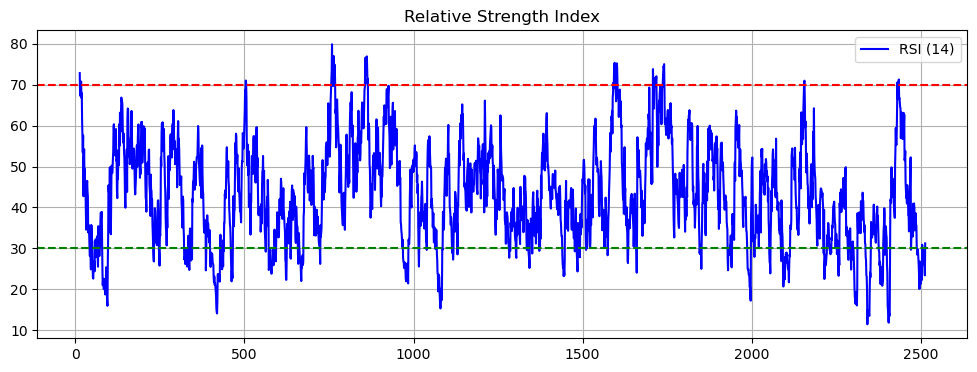

In [84]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['RSI_14'], label="RSI (14)", color="blue")
plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")
plt.title("Relative Strength Index")
plt.legend()
plt.grid(True)
plt.show()


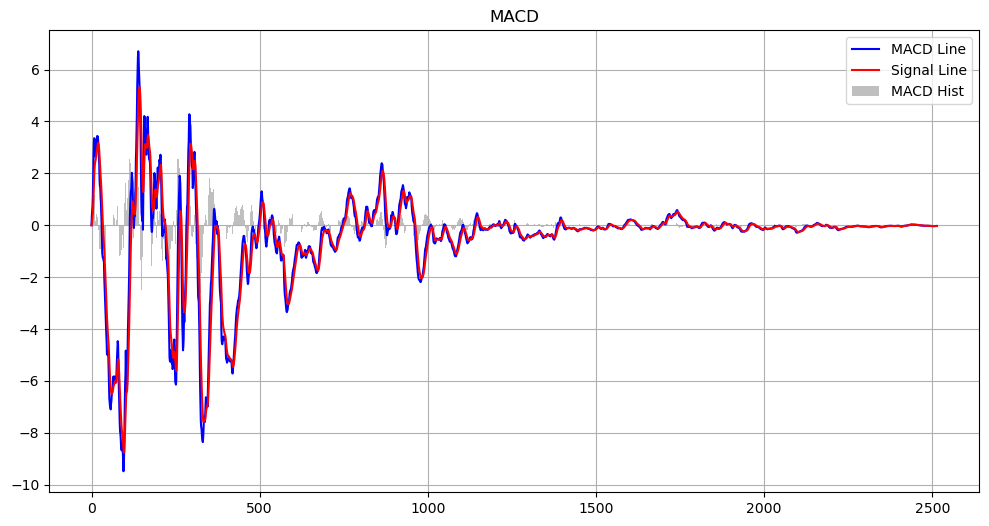

In [85]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['MACD_Line'], label="MACD Line", color="blue")
plt.plot(df.index, df['MACD_Signal'], label="Signal Line", color="red")
plt.bar(df.index, df['MACD_Hist'], label="MACD Hist", color="gray", alpha=0.5)
plt.title("MACD")
plt.legend()
plt.grid(True)
plt.show()


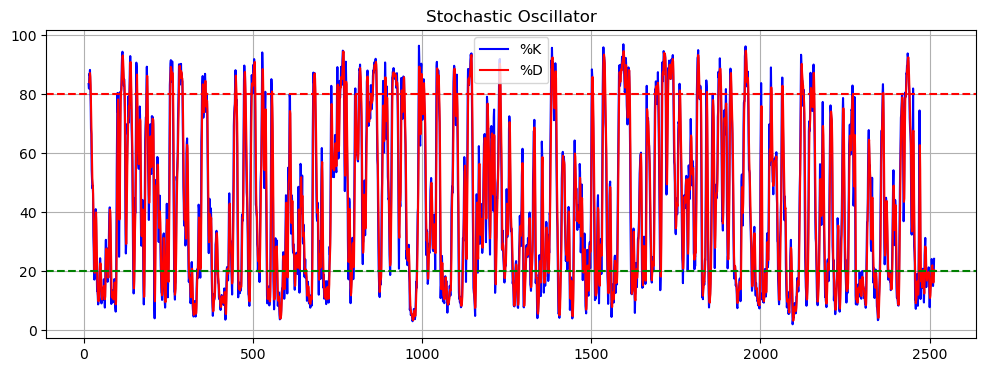

In [86]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['StochK_14'], label="%K", color="blue")
plt.plot(df.index, df['StochD_14'], label="%D", color="red")
plt.axhline(80, color="red", linestyle="--")
plt.axhline(20, color="green", linestyle="--")
plt.title("Stochastic Oscillator")
plt.legend()
plt.grid(True)
plt.show()


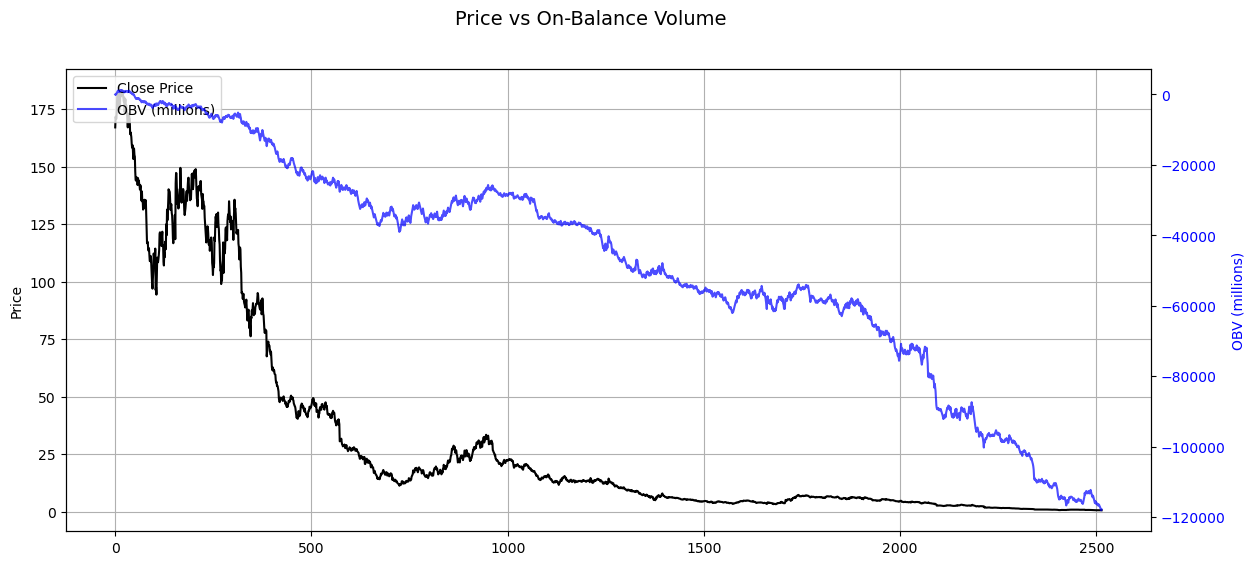

In [87]:

fig, ax1 = plt.subplots(figsize=(14,6))

# --- Plot Price on left y-axis ---
ax1.plot(df.index, df['Close'], label="Close Price", color="black")
ax1.set_ylabel("Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# --- Plot OBV on right y-axis ---
ax2 = ax1.twinx()
ax2.plot(df.index, df['OBV']/1e6, label="OBV (millions)", color="blue", alpha=0.7)
ax2.set_ylabel("OBV (millions)", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# --- Title & Grid ---
fig.suptitle("Price vs On-Balance Volume", fontsize=14)
ax1.grid(True)

# --- Legends ---
lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.show()


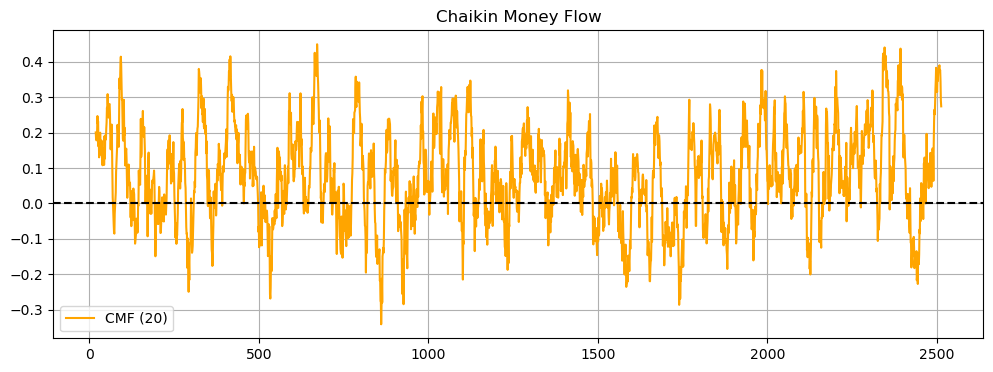

In [88]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['CMF_20'], label="CMF (20)", color="orange")
plt.axhline(0, color="black", linestyle="--")
plt.title("Chaikin Money Flow")
plt.legend()
plt.grid(True)
plt.show()


In [89]:
df_nasdaq=pd.read_csv('assets/HistoricalData_1757233684964.csv')

In [90]:
df_nasdaq.shape

(2517, 5)

In [91]:
df_nasdaq.info()
df_nasdaq['NADAQ CLOSE']=df_nasdaq['Close/Last']
df_nasdaq.drop(columns=['Close/Last','Open','High','Low'], inplace=True)
df_nasdaq['Date'] = pd.to_datetime(df_nasdaq['Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2517 non-null   object 
 1   Close/Last  2517 non-null   float64
 2   Open        2517 non-null   float64
 3   High        2517 non-null   float64
 4   Low         2517 non-null   float64
dtypes: float64(4), object(1)
memory usage: 98.4+ KB


In [92]:
df_nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2517 non-null   datetime64[ns]
 1   NADAQ CLOSE  2517 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.5 KB


In [93]:
df=pd.merge(df, df_nasdaq, on='Date', how='inner')

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2514 non-null   datetime64[ns]
 1   Volume        2514 non-null   float64       
 2   Open          2514 non-null   float64       
 3   High          2514 non-null   float64       
 4   Low           2514 non-null   float64       
 5   Close         2514 non-null   float64       
 6   SMA_20        2495 non-null   float64       
 7   SMA_50        2465 non-null   float64       
 8   SMA_200       2315 non-null   float64       
 9   EMA_20        2514 non-null   float64       
 10  EMA_50        2514 non-null   float64       
 11  EMA_200       2514 non-null   float64       
 12  MACD_Line     2514 non-null   float64       
 13  MACD_Signal   2514 non-null   float64       
 14  MACD_Hist     2514 non-null   float64       
 15  RSI_7         2508 non-null   float64 

In [96]:
import os
df.to_csv('./assets/NVDIA_DATA.csv', index=True)